In [1]:
import numpy as np
import scipy.stats as sts
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import seaborn
%matplotlib inline

# Гречишкин Денис ПМ-31

# Лабораторная работа №6

# Часть 7.4 (Примеры для совместного обсуждения)

Импорт данных

In [2]:
data_1_2 = pd.read_excel('Data_7.xlsx', header = 0)
d_1_2 = pd.DataFrame(data_1_2)
v_1_2 = d_1_2.astype(float)
print(v_1_2)
v_1 = v_1_2['Выборка 1'].dropna()
v_1.head(5)

    Выборка 1  Выборка 2
0        6.01       1.29
1        8.71       7.27
2        2.12      27.78
3        8.61      10.91
4        3.38       6.56
..        ...        ...
95        NaN       2.01
96        NaN       2.08
97        NaN      12.91
98        NaN       9.74
99        NaN       5.05

[100 rows x 2 columns]


0    6.01
1    8.71
2    2.12
3    8.61
4    3.38
Name: Выборка 1, dtype: float64

ПРИМЕР 1

Text(0.5, 1.0, 'Гистограмма относительных частот')

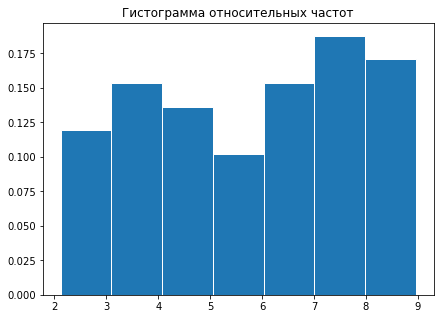

In [3]:
plt.figure(figsize = [7, 5])
plt.hist(v_1, bins = 'sturges', edgecolor = 'white', density = True)
plt.title('Гистограмма относительных частот')

Вид гистограммы не противоречит гипотезе о равномерном распределении генеральной совокупности. Проверим эту гипотезу, используя критерий согласия Пирсона (хи-квадрат).

In [4]:
gr_v_1 = np.histogram(v_1, bins = 'sturges')
print('Наблюдаемые частоты:', gr_v_1[0])
print('Границы интервалов:', gr_v_1[1])
f_1 = gr_v_1[0]
g_1 = gr_v_1[1]
p_teor_1 = np.full(len(f_1), 1/len(f_1))
print('Теоретические вероятности попадания на интервалы', p_teor_1)
f_exp_1 = p_teor_1 * len(v_1)
print('Гипотетические частоты n*pi', f_exp_1)
xi2_v_1 = np.sum((f_1 - f_exp_1)**2/f_exp_1)
print('Выборочное значение статистики:', xi2_v_1)
p_value = 1 - sts.chi2(len(f_1 ) - 2 - 1).cdf(xi2_v_1)
print('p-значение:', p_value)
sts.chisquare(f_1, f_exp_1, ddof = 2, axis = 0)

Наблюдаемые частоты: [ 7  9  8  6  9 11 10]
Границы интервалов: [2.12       3.09714286 4.07428571 5.05142857 6.02857143 7.00571429
 7.98285714 8.96      ]
Теоретические вероятности попадания на интервалы [0.14285714 0.14285714 0.14285714 0.14285714 0.14285714 0.14285714
 0.14285714]
Гипотетические частоты n*pi [8.57142857 8.57142857 8.57142857 8.57142857 8.57142857 8.57142857
 8.57142857]
Выборочное значение статистики: 2.0666666666666664
p-значение: 0.7234984676925954


Power_divergenceResult(statistic=2.0666666666666664, pvalue=0.7234984676925954)

Вывод: гипотеза о принадлежности выборки равномерно распределенной генеральной совокупности принимается, если уровень значимости меньше 0.7234984676925954

ПРИМЕР 2

Text(0.5, 1.0, 'Гистограмма относительных частот')

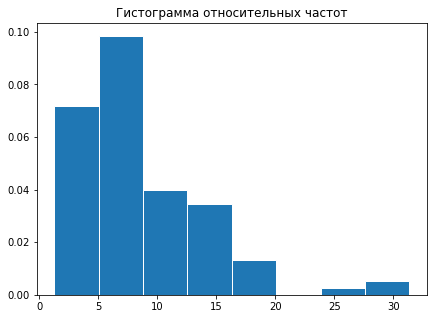

In [5]:
v_2 = v_1_2['Выборка 2'].dropna()
v_2.head(5)
plt.figure(figsize = [7, 5])
plt.hist(v_2, bins = 'sturges', edgecolor = 'white', density = True)
plt.title('Гистограмма относительных частот')

Text(0.5, 1.0, 'Гистограмма относительных частот преобразованной выборки')

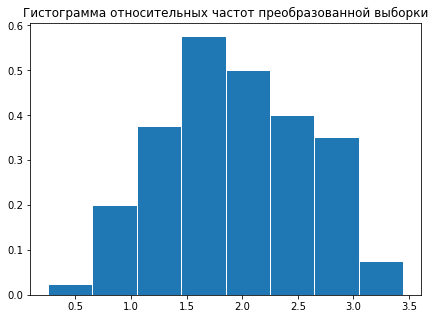

In [6]:
v_2_log = np.log(v_2)
plt.figure(figsize = [7, 5])
plt.hist(v_2_log, bins = 'sturges', edgecolor = 'white', density = True)
plt.title('Гистограмма относительных частот преобразованной выборки')

In [7]:
Sp, p = sts.shapiro(v_2_log)
print('p-значение:', p)

p-значение: 0.8771436810493469


Выводы: если исходить из p-значения то нет оснований отвергать гипотезу принадлежности преобразованных данных нормально распределенной генеральной совокупности.

Построим Q-Q график

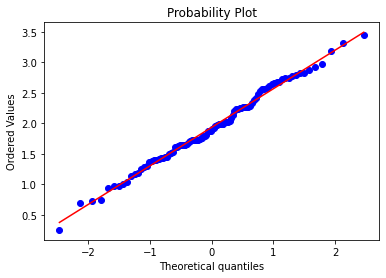

In [8]:
res = sts.probplot(v_2_log, plot = plt)

# Часть 7.5(Задания для самостоятельного выполнения)

## Задание 1: В файле «Data_7_1» приведены массивы результатов наблюдения нескольких случайных величин. Будем рассматривать каждый из массивов как случайную выборку из генеральной совокупности с 
неизвестным законом распределения (для каждого массива генеральная совокупность своя). Экспортируйте данные. Для каждой из выборок постройте гистограмму относительных частот и на основе визуального качественного анализа гистограмм отберите три выборки: выборку А, позволяющую выдвинуть гипотезу о принадлежности нормальному распределению генеральной совокупности; выборку В, позволяющую выдвинуть гипотезу о равномерном распределении генеральной совокупности; выборку С, позволяющую выдвинуть гипотезу о показательном распределении генеральной совокупности. $\newline$
Если среди массивов данных нет ни одного похожего на выборку из генеральной совокупности с показательным законом распределения, то попробуйте преобразовать один из них таким образом, чтобы к полученной выборке гипотеза о показательном распределении генеральной совокупности подходила. 


## Решение: для начала импортируем данные из файла

In [9]:
data_2_2 = pd.read_excel('Data_7_1.xlsx', header = 0)
d_2_2 = pd.DataFrame(data_2_2)
d_2_2 = d_2_2.replace('-', np.nan)
v_2_2 = d_2_2.astype(float)
print(v_2_2)

     Тест:Тест по теме "Множества и бинарные отношения" для групп ПМ-21,22, ИВТ-21,22 (Значение)  \
0                                                  NaN                                             
1                                                  0.8                                             
2                                                  0.8                                             
3                                                  0.8                                             
4                                                  0.6                                             
..                                                 ...                                             
116                                                0.7                                             
117                                                1.2                                             
118                                                1.0                                             


Выделим из v_2_2 пять выборок с помощью функции dropna и построим гистограммы с помощью функции plt.hist

Text(0.5, 1.0, 'Гистограмма относительных частот 1-й выборки')

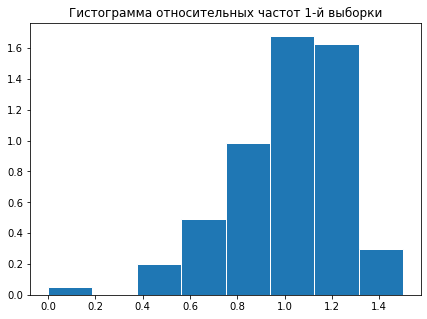

In [10]:
v_01 = v_2_2['Тест:Тест по теме "Множества и бинарные отношения" для групп ПМ-21,22, ИВТ-21,22 (Значение)'].dropna()
#print(v_01)
#v_01.head(5)
plt.figure(figsize = [7, 5])
plt.hist(v_01, bins = 'sturges', edgecolor = 'white', density = True)
plt.title('Гистограмма относительных частот 1-й выборки')

Text(0.5, 1.0, 'Гистограмма относительных частот 2-й выборки')

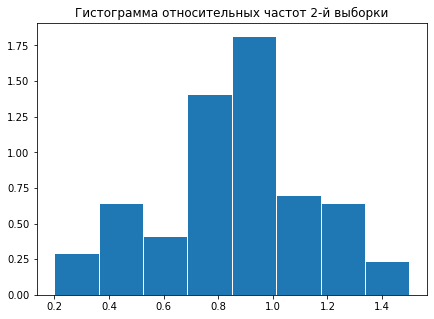

In [11]:
v_02 = v_2_2['Тест:Тест по теме "Элементы комбинаторики" для групп ПМ-21,22, ИВТ-21,22 (Значение)'].dropna()
#print(v_01)
#v_01.head(5)
plt.figure(figsize = [7, 5])
plt.hist(v_02, bins = 'sturges', edgecolor = 'white', density = True)
plt.title('Гистограмма относительных частот 2-й выборки')

Text(0.5, 1.0, 'Гистограмма относительных частот 3-й выборки')

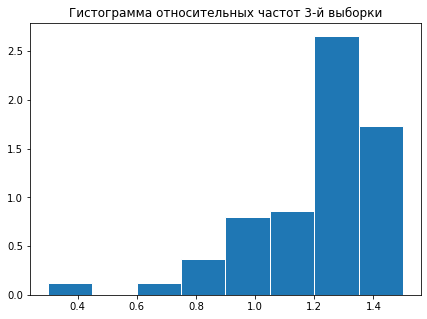

In [12]:
v_03 = v_2_2['Тест:Тест по теме "Булевы функции и способы их задания" для групп ПМ-21,22, ИВТ-21,22,23 (Значение)'].dropna()
#print(v_01)
#v_01.head(5)
plt.figure(figsize = [7, 5])
plt.hist(v_03, bins = 'sturges', edgecolor = 'white', density = True)
plt.title('Гистограмма относительных частот 3-й выборки')

Text(0.5, 1.0, 'Гистограмма относительных частот 4-й выборки')

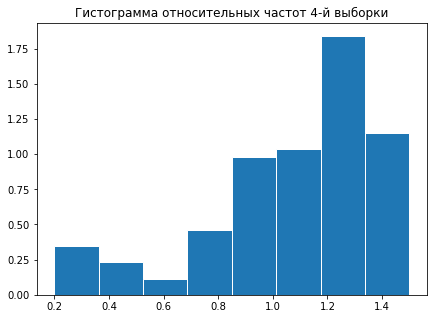

In [13]:
v_04 = v_2_2['Тест:Тест по теме "Представление булевых функций формулами специального вида" для групп ПМ-21,22, ИВТ-21-23 (Значение)'].dropna()
#print(v_01)
#v_01.head(5)
plt.figure(figsize = [7, 5])
plt.hist(v_04, bins = 'sturges', edgecolor = 'white', density = True)
plt.title('Гистограмма относительных частот 4-й выборки')

Text(0.5, 1.0, 'Гистограмма относительных частот 5-й выборки')

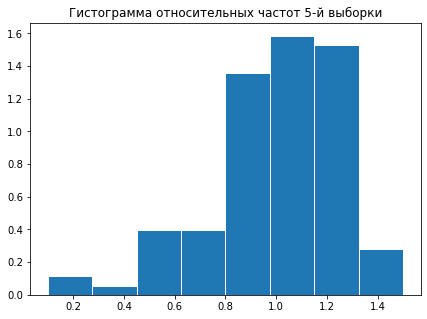

In [14]:
v_05 = v_2_2['Тест:Тест по теме "Минимизация дизъюнктивных нормальных форм" для групп ПМ-21,22, ИВТ-21,22,23 (Значение)'].dropna()
#print(v_01)
#v_01.head(5)
plt.figure(figsize = [7, 5])
plt.hist(v_05, bins = 'sturges', edgecolor = 'white', density = True)
plt.title('Гистограмма относительных частот 5-й выборки')

ПРЕОБРАЗОВАНИЕ ГИСТОГРАММЫ ДЛЯ ВЫБОРКИ C

Если судить по форме гистограммы, 3-я выборка больше всего подходит на роль выборки C. Модифицируем 3-ю выборку: перевернём её и прибавим максимальное значение исходной выборки.

Text(0.5, 1.0, 'Гистограмма относительных частот измененной 3-й выборки')

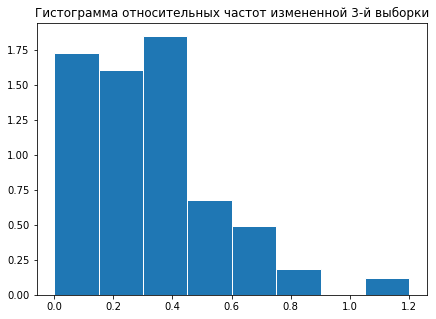

In [44]:
#min_v03 = min(-v_03)
#SIZE = d_2_2.size/5
final_preobr = max(v_03 + 0.001)
v_c = -v_03 + final_preobr
- final_preobr
plt.figure(figsize = [7, 5])
plt.hist(v_c, bins = 'sturges', edgecolor = 'white', density = True)
plt.title('Гистограмма относительных частот измененной 3-й выборки')

На роль выборки A подойдет **2-я выборка**, на роль выборки B подойдет **5-я выборка**, на роль выборки C подойдет **3-я модифицированная выборка**

## Задание 2. Проверьте гипотезу о том, что выборка А взята из генеральной совокупности, имеющей нормальное распределение, с помощью критерия согласия хи-квадрат. 
Решение должно быть подробным, с выполнением всех шагов алгоритма и отслеживанием корректности применения. Сделайте выводы. 

## Решение: 
пусть X генеральная совокупоность, из которой взята выборка A

1. Формируем гипотезы $\newline$ $H_0$: X имеет нормальное распределение; $H_1 = \overline H_0$
2. Выберем уровень значимости $\alpha = 0.1$
3. Разбиваем числовую ось на  𝑙 интервалов $\delta_k$ точками $a_1, a_2, ..., a_{l-1}$, так что $\delta_k = [a_{k-1}, a_k)$, k = 2,3,...,𝑙 − 1, $\delta_1= (-\infty,1), \delta_l = [a_{l-1}, +\infty)$.
Выбираем статистику $Z = \sum_{k = 1}^l \frac{n}{p_k} (M_k - p_k)^2$, где $p_k$- теоретические вероятности, а $M_k$- частоты попадания сл. величин $X_1, X_2, ..., X_n$ в интервалы $\delta_k$. $\newline$
При 𝑛 >> 1 $Z \sim  \chi^2(l-s-1)$
Для этого пункта воспользуемся функцией np.histogram

In [16]:
gr_v_2, bin_edges_2 = np.histogram(v_02, bins = 'sturges')
m = np.mean(v_02)
sigma = np.std(v_02, ddof = 1)
print('Наблюдаемые частоты:', gr_v_2)
print('Границы интервалов:', bin_edges_2)
f_2 = gr_v_2
g_2 = bin_edges_2
ps2 = []
for i in range(bin_edges_2.size - 1):
    ps2.append(sts.norm(m, sigma).cdf(bin_edges_2[i+1])-sts.norm(m, sigma).cdf(bin_edges_2[i]))

print('Теоретические вероятности попадания на интервалы', np.round(ps2, 5))
#print('Гипотетические частоты', v_02.size*np.round(p_teor_2, 3))
f_exp_2 = v_02.size*np.round(ps2, 5)
print('Гипотетические частоты n*pi', f_exp_2)

Наблюдаемые частоты: [ 5 11  7 24 31 12 11  4]
Границы интервалов: [0.2    0.3625 0.525  0.6875 0.85   1.0125 1.175  1.3375 1.5   ]
Теоретические вероятности попадания на интервалы [0.02892 0.07772 0.15149 0.21418 0.21969 0.16348 0.08825 0.03455]
Гипотетические частоты n*pi [ 3.0366   8.1606  15.90645 22.4889  23.06745 17.1654   9.26625  3.62775]


Преобразуем массив с гипотетическими частотами так чтобы можно было применить критерий согласия "хи-квадрат"

In [17]:
ps_2_1 = [ps2[0] + ps2[1], ps2[2], ps2[3], ps2[4], ps2[5], ps2[6] + ps2[7]]
gr_v_2_1 = [gr_v_2[0] + gr_v_2[1], gr_v_2[2], gr_v_2[3], gr_v_2[4], gr_v_2[5], gr_v_2[6] + gr_v_2[7]]
print('ПОСЛЕ ОБЪЕДИНЕНИЯ ОТРЕЗКОВ:')
print('Наблюдаемые частоты:', gr_v_2_1)
print('Теоретические вероятности попадания на интервалы', np.round(ps_2_1, 5))
#print('Гипотетические частоты', v_02.size*np.round(p_teor_2, 3))
f_exp_2_1 = v_02.size*np.round(ps_2_1, 5)
print('Гипотетические частоты n*pi', f_exp_2_1)

ПОСЛЕ ОБЪЕДИНЕНИЯ ОТРЕЗКОВ:
Наблюдаемые частоты: [16, 7, 24, 31, 12, 15]
Теоретические вероятности попадания на интервалы [0.10664 0.15149 0.21418 0.21969 0.16348 0.1228 ]
Гипотетические частоты n*pi [11.1972  15.90645 22.4889  23.06745 17.1654  12.894  ]


4. Строим критическую область: $G_{\alpha} = \left\{Z > \chi^2_{1-\alpha}(l-s-1) \right\} = \left\{Z > \chi^2_{0.9}(6-2-1)\right\} = \left\{Z > \chi^2_{0.9}(3)\right\}$

5. Считаем выборочное значение статистики Z

In [18]:
xi2_v_2 = 0
for i in range(len(gr_v_2_1)):
    xi2_v_2 += (v_02.size/ps_2_1[i]*(gr_v_2_1[i]/v_02.size - ps_2_1[i])**2)
print('Выборочное значение статистики:', xi2_v_2)
z_min = (sts.chi2(6)).ppf(0.9)
print('крайняя левая граница критической области', z_min)

Выборочное значение статистики: 11.774335821975608
крайняя левая граница критической области 10.644640675668422


6. Выборочное значение статистики попало в критическую область, значит основная гипотеза из пункта 1 отвергается

Найдем дополнительно p-значение для получения окончательных выводов

In [19]:
p_value = 1 - sts.chi2(3).cdf(xi2_v_2)
print('p-значение:', p_value)

p-значение: 0.008197557460108307


ВЫВОД: гипотеза о принадлежности выборки равномерно распределенной генеральной совокупности принимается, если уровень значимости меньше 0.008197557460108307

## Задание 3: Проверьте гипотезу о том, что выборка С (исходная или полученная путем преобразования) взята из генеральной совокупности, имеющей показательное распределение. Используйте критерий согласия 
хи-квадрат. Решение должно быть подробным, с выполнением всех шагов алгоритма и отслеживанием корректности применения. Сделайте выводы. 

## Решение: 
пусть Y генеральная совокупоность, из которой взята выборка C

1. Формируем гипотезы $\newline$ $H_0$: Y имеет нормальное распределение; $H_1 = \overline H_0$
2. Выберем уровень значимости $\alpha = 0.1$
3. Разбиваем числовую ось на l интервалов $\delta_k$ точками $a_1, a_2, ..., a_{l-1}$, так что $\delta_k = [a_{k-1}, a_k)$, k = 2,3,...,𝑙 − 1, $\delta_1= (-\infty,1), \delta_l = [a_{l-1}, +\infty)$.
Выбираем статистику $Z = \sum_{k = 1}^l \frac{n}{p_k} (M_k - p_k)^2$, где $p_k$- теоретические вероятности, а $M_k$- частоты попадания сл. величин $Y_1, Y_2, ..., Y_n$ в интервалы $\delta_k$. $\newline$
При 𝑛 >> 1 $Z \sim  \chi^2(l-s-1)$ $\newline$
Для этого пункта воспользуемся функцией np.histogram

In [48]:
gr_v_3, bin_edges_3 = np.histogram(v_c, bins = 'sturges')
m1 = np.mean(v_c)
print('Наблюдаемые частоты:', gr_v_3)
print('Границы интервалов:', bin_edges_3)
f_3 = gr_v_3
g_3 = bin_edges_3
ps3 = []
for i in range(bin_edges_3.size - 1):
    ps3.append(sts.expon(0, m1).cdf(bin_edges_3[i+1])-sts.expon(0, m1).cdf(bin_edges_3[i]))

print('Теоретические вероятности попадания на интервалы', np.round(ps3, 3))

f_exp_3 = v_c.size*np.round(ps3, 5)
print('Гипотетические частоты n*pi', f_exp_3)

Наблюдаемые частоты: [28 26 30 11  8  3  0  2]
Границы интервалов: [1.000e-03 1.510e-01 3.010e-01 4.510e-01 6.010e-01 7.510e-01 9.010e-01
 1.051e+00 1.201e+00]
Теоретические вероятности попадания на интервалы [0.385 0.236 0.145 0.089 0.055 0.034 0.021 0.013]
Гипотетические частоты n*pi [41.56704 25.51716 15.66324  9.61524  5.9022   3.6234   2.22372  1.36512]


Преобразуем массив с гипотетическими частотами так чтобы можно было применить критерий согласия "хи-квадрат"

In [47]:
ps_3_1 = [ps3[0], ps3[1], ps3[2], ps3[3], ps3[4], ps3[5] + ps3[6] + ps3[7]]
gr_v_3_1 = [gr_v_3[0], gr_v_3[1], gr_v_3[2], gr_v_3[3], gr_v_3[4], gr_v_3[5] + gr_v_3[6] + gr_v_3[7]]
print('ПОСЛЕ ОБЪЕДИНЕНИЯ ОТРЕЗКОВ:')
print('Наблюдаемые частоты:', gr_v_3_1)
print('Теоретические вероятности попадания на интервалы', np.round(ps_3_1, 3))

f_exp_3_1 = v_c.size*np.round(ps_3_1, 5)
print('Гипотетические частоты n*pi', f_exp_3_1)

ПОСЛЕ ОБЪЕДИНЕНИЯ ОТРЕЗКОВ:
Наблюдаемые частоты: [28, 26, 30, 11, 8, 5]
Теоретические вероятности попадания на интервалы [0.385 0.236 0.145 0.089 0.055 0.067]
Гипотетические частоты n*pi [41.56704 25.51716 15.66324  9.61524  5.9022   7.21332]


4. Строим критическую область: $G_{\alpha} = \left\{Z > \chi^2_{1-\alpha}(l-s-1) \right\} = \left\{Z > \chi^2_{0.9}(6-1-1)\right\} = \left\{Z > \chi^2_{0.9}(4)\right\}$

5. Считаем выборочное значение статистики Z

In [49]:
xi2_v_3 = 0
for i in range(len(gr_v_3_1)):
    xi2_v_3 += (v_c.size/ps_3_1[i]*(gr_v_3_1[i]/v_c.size - ps_3_1[i])**2)
print('Выборочное значение статистики:', xi2_v_3)
z_min = (sts.chi2(4)).ppf(0.9)
print('крайняя левая граница критической области', z_min)

Выборочное значение статистики: 19.18230850694309
крайняя левая граница критической области 7.779440339734858


6. Выборочное значение статистики попало в критическую область, значит основная гипотеза из пункта 1 отвергается

Найдем дополнительно p-значение для получения окончательных выводов

In [50]:
p_value = 1 - sts.chi2(4).cdf(xi2_v_3)
print('p-значение:', p_value)

p-значение: 0.0007236989223801116


ВЫВОД: гипотеза о принадлежности выборки равномерно распределенной генеральной совокупности принимается, если уровень значимости меньше 0.0007236989223801116, т.е с очень малой вероятностью можно утвержжать что выборка 3 взята из генеральной совокупности имеющей равномерное распределение

## Задание 4:
1)  Преобразуйте данные, применив к выборкам А, В и С преобразование Бокса-Кокса (далее АА, ВВ и СС – преобразованные данные).  
2)  Постройте гистограммы А и АА, В и ВВ, С и СС. Сопоставьте гистограммы прообразов и образов. Результаты прокомментируйте.  
3)  С помощью критерия Шапиро – Уилка (используйте функцию shapiro() модуля scipy.stats) проверьте для всех шести выборок гипотезы о том, 
что выборки принадлежат нормально распределенным генеральным совокупностям. Результаты сопоставьте и прокомментируйте. 
4)  Для всех шести выборок постройте Q-Q – график. Сопоставьте графики прообразов и образов. Результаты прокомментируйте и сопоставьте с результатами п. 3). 

## Решение:

## Пункт 1: воспользуемся встроенной в питон функцией sts.boxcox

In [53]:
v_aa, lambda_a, _ = sts.boxcox(v_02, lmbda = None, alpha = 0.1)
v_bb, lambda_b, _ = sts.boxcox(v_05, lmbda = None, alpha = 0.1)
v_cc, lambda_c, _ = sts.boxcox(v_c, lmbda = None, alpha = 0.1)
print('ПРЕОБРАЗОВАННАЯ ВЫБОРКА A:')
print(v_aa)
print('ПРЕОБРАЗОВАННАЯ ВЫБОРКА B:')
print(v_bb)
print('ПРЕОБРАЗОВАННАЯ ВЫБОРКА C:')
print(v_cc)

ПРЕОБРАЗОВАННАЯ ВЫБОРКА A:
[-0.47342511  0.2034201  -0.099074   -0.099074   -0.38364789  0.
 -0.19618211  0.          0.41306348  0.41306348  0.10087666 -0.56000791
  0.2034201  -0.29112411 -0.099074    0.10087666 -0.19618211 -0.19618211
 -0.29112411 -0.47342511 -0.72057841  0.         -0.19618211 -0.29112411
 -0.38364789 -0.29112411 -0.099074    0.         -0.47342511 -0.72057841
 -0.47342511  0.          0.2034201  -0.19618211  0.10087666 -0.64274386
 -0.099074   -0.56000791 -0.29112411  0.10087666 -0.56000791  0.2034201
  0.2034201  -0.19618211  0.         -0.099074   -0.29112411  0.10087666
  0.          0.10087666  0.2034201  -0.19618211 -0.38364789 -0.099074
  0.51997885 -0.19618211 -0.19618211  0.10087666  0.10087666 -0.38364789
  0.3075153   0.2034201  -0.56000791  0.41306348  0.          0.
 -0.38364789 -0.64274386  0.10087666 -0.29112411  0.         -0.56000791
 -0.29112411  0.          0.          0.3075153  -0.38364789 -0.29112411
  0.          0.         -0.38364789 -0.473

## Пункт 2

Text(0.5, 1.0, 'Гистограмма относительных частот выборки AA')

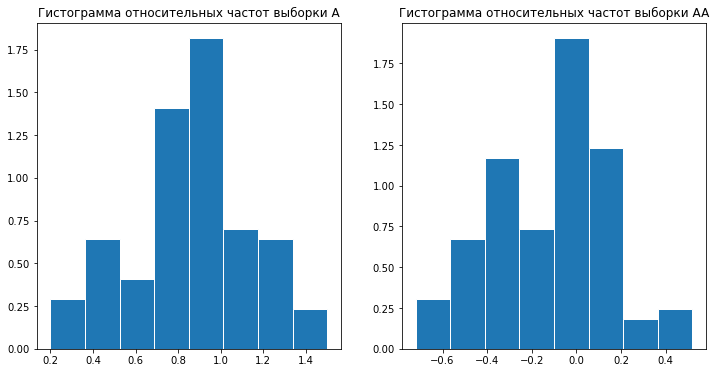

In [54]:
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
plt.hist(v_02, bins = 'sturges', edgecolor = 'white', density = True)
plt.title('Гистограмма относительных частот выборки A')
plt.subplot(1, 2, 2)
plt.hist(v_aa, bins = 'sturges', edgecolor = 'white', density = True)
plt.title('Гистограмма относительных частот выборки AA')

Text(0.5, 1.0, 'Гистограмма относительных частот выборки BB')

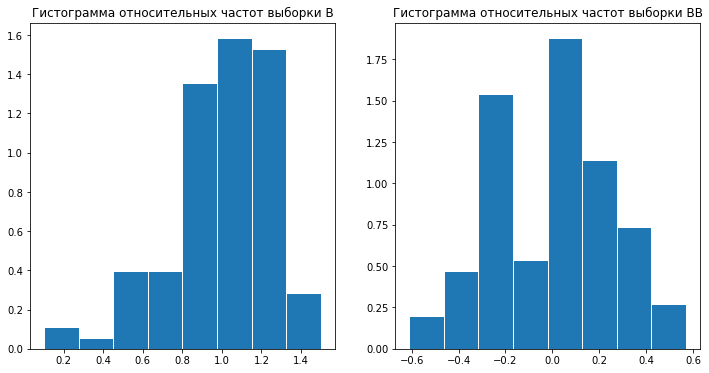

In [55]:
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
plt.hist(v_05, bins = 'sturges', edgecolor = 'white', density = True)
plt.title('Гистограмма относительных частот выборки B')
plt.subplot(1, 2, 2)
plt.hist(v_bb, bins = 'sturges', edgecolor = 'white', density = True)
plt.title('Гистограмма относительных частот выборки BB')

Text(0.5, 1.0, 'Гистограмма относительных частот выборки CC')

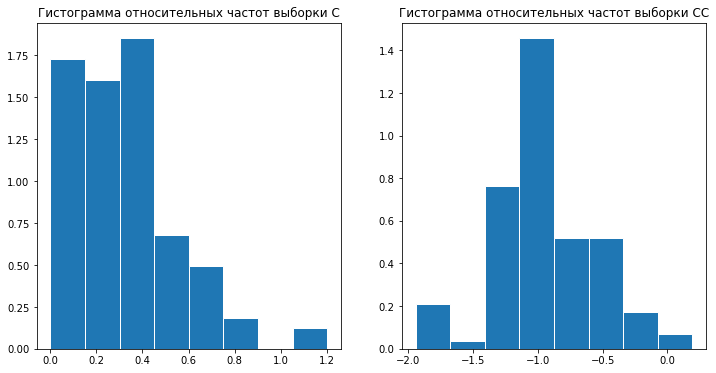

In [56]:
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
plt.hist(v_c, bins = 'sturges', edgecolor = 'white', density = True)
plt.title('Гистограмма относительных частот выборки C')
plt.subplot(1, 2, 2)
plt.hist(v_cc, bins = 'sturges', edgecolor = 'white', density = True)
plt.title('Гистограмма относительных частот выборки CC')

Выборка А проверялась на соответствие нормальному распределению, поэтому измененная гистограмма не сильно отличается от гистограммы самой выборки. Преобразованные выборки BB и CC сильно отличаются от исходников, и больше похожи на функцию плотности нормального распределения

## Пункт 3(ИСПРАВЛЕННЫЙ): применим функцию shapiro() модуля scipy.stats ко всем шести выборкам

In [58]:
sp_a, p_a = sts.shapiro(v_02)
sp_aa, p_aa = sts.shapiro(v_aa)
sp_b, p_b = sts.shapiro(v_05)
sp_bb, p_bb = sts.shapiro(v_bb)
sp_c, p_c = sts.shapiro(v_c)
sp_cc, p_cc = sts.shapiro(v_cc)
print('p-value для выборки A', p_a)
print('p-value для выборки AA', p_aa)
print('p-value для выборки B', p_b)
print('p-value для выборки BB', p_bb)
print('p-value для выборки C', p_c)
print('p-value для выборки CC', p_cc)

p-value для выборки A 0.08102016896009445
p-value для выборки AA 0.14273950457572937
p-value для выборки B 0.0019938733894377947
p-value для выборки BB 0.06385146826505661
p-value для выборки C 3.5367648365536297e-07
p-value для выборки CC 0.0068495976738631725


Для выборок B, BB, C, CC не получится принять гипотеззу о нормальном распределении соответствующих генеральных совокупностей из-за того что p-значения слишком малы. 
При этом, для выборки AA мы можем принять гипотезу, на уровне значимости $\alpha \lt 0.08102016896009445$,а для выборки AA мы можем принять гипотезу, на уровне значимости $\alpha \lt 0.14273950457572937$

## Пункт 4:

Text(0.5, 1.0, 'выборка AA')

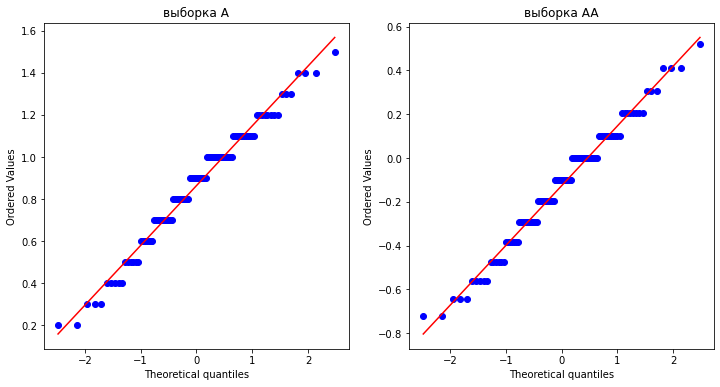

In [60]:
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
res1 = sts.probplot(v_02, plot = plt)
plt.title('выборка A')
plt.subplot(1, 2, 2)
res1 = sts.probplot(v_aa, plot = plt)
plt.title('выборка AA')

Text(0.5, 1.0, 'выборка ВВ')

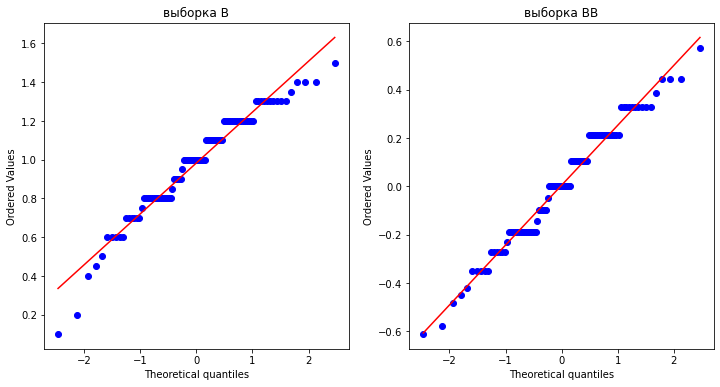

In [61]:
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
res1 = sts.probplot(v_05, plot = plt)
plt.title('выборка В')
plt.subplot(1, 2, 2)
res1 = sts.probplot(v_bb, plot = plt)
plt.title('выборка ВВ')

Text(0.5, 1.0, 'выборка СС')

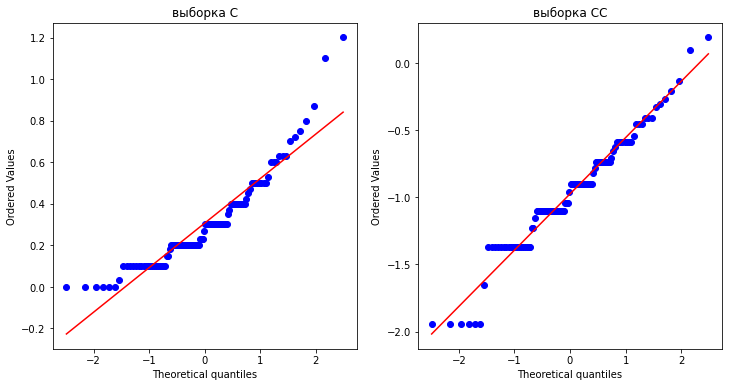

In [59]:
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
res1 = sts.probplot(v_c, plot = plt)
plt.title('выборка С')
plt.subplot(1, 2, 2)
res1 = sts.probplot(v_cc, plot = plt)
plt.title('выборка СС')

Из-за того что выборки A и AA проверяются на нормальное распределение, отличия между приближениями A и AA незначительные и обе выборки достаточно хорошо ложаться на кривую. BB намного лучше ложится на прямую, чем B (особенно хорошо это видно из разницы на хвостах), но в любом случае обе выборки отклоняются достаточно сильно, поэтому не получится принять гипотезы о нормальном распределении ген. совокупностей выборок B и BB. C выборками C и CC ситуация аналогичная выборкам B и BB соответственно.